<a href="https://colab.research.google.com/github/MarkLee1435/Soft-Robotics-263F/blob/main/Homework3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output # Only for iPython

#Helper function

In [ ]:
def crossMat(a):
    """
    Returns the cross product matrix of vector 'a'.

    Parameters:
    a : np.ndarray
        A 3-element array representing a vector.

    Returns:
    A : np.ndarray
        The cross product matrix corresponding to vector 'a'.
    """
    A = np.array([[0, -a[2], a[1]],
                  [a[2], 0, -a[0]],
                  [-a[1], a[0], 0]])

    return A

#Gradient and Hessian of elastic energies

In [ ]:
def gradEb(xkm1, ykm1, xk, yk, xkp1, ykp1, curvature0, l_k, EI):
    """
    Returns the derivative of bending energy E_k^b with respect to
    x_{k-1}, y_{k-1}, x_k, y_k, x_{k+1}, and y_{k+1}.

    Parameters:
    xkm1, ykm1 : float
        Coordinates of the previous node (x_{k-1}, y_{k-1}).
    xk, yk : float
        Coordinates of the current node (x_k, y_k).
    xkp1, ykp1 : float
        Coordinates of the next node (x_{k+1}, y_{k+1}).
    curvature0 : float
        Discrete natural curvature at node (xk, yk).
    l_k : float
        Voronoi length of node (xk, yk).
    EI : float
        Bending stiffness.

    Returns:
    dF : np.ndarray
        Derivative of bending energy.
    """

    # Nodes in 3D
    node0 = np.array([xkm1, ykm1, 0.0])
    node1 = np.array([xk, yk, 0])
    node2 = np.array([xkp1, ykp1, 0])

    # Unit vectors along z-axis
    m2e = np.array([0, 0, 1])
    m2f = np.array([0, 0, 1])

    kappaBar = curvature0

    # Initialize gradient of curvature
    gradKappa = np.zeros(6)

    # Edge vectors
    ee = node1 - node0
    ef = node2 - node1

    # Norms of edge vectors
    norm_e = np.linalg.norm(ee)
    norm_f = np.linalg.norm(ef)

    # Unit tangents
    te = ee / norm_e
    tf = ef / norm_f

    # Curvature binormal
    kb = 2.0 * np.cross(te, tf) / (1.0 + np.dot(te, tf))

    chi = 1.0 + np.dot(te, tf)
    tilde_t = (te + tf) / chi
    tilde_d2 = (m2e + m2f) / chi

    # Curvature
    kappa1 = kb[2]

    # Gradient of kappa1 with respect to edge vectors
    Dkappa1De = 1.0 / norm_e * (-kappa1 * tilde_t + np.cross(tf, tilde_d2))
    Dkappa1Df = 1.0 / norm_f * (-kappa1 * tilde_t - np.cross(te, tilde_d2))

    # Populate the gradient of kappa
    gradKappa[0:2] = -Dkappa1De[0:2]
    gradKappa[2:4] = Dkappa1De[0:2] - Dkappa1Df[0:2]
    gradKappa[4:6] = Dkappa1Df[0:2]

    # Gradient of bending energy
    dkappa = kappa1 - kappaBar
    dF = gradKappa * EI * dkappa / l_k

    return dF

In [ ]:
def hessEb(xkm1, ykm1, xk, yk, xkp1, ykp1, curvature0, l_k, EI):
    """
    Returns the Hessian (second derivative) of bending energy E_k^b
    with respect to x_{k-1}, y_{k-1}, x_k, y_k, x_{k+1}, and y_{k+1}.

    Parameters:
    xkm1, ykm1 : float
        Coordinates of the previous node (x_{k-1}, y_{k-1}).
    xk, yk : float
        Coordinates of the current node (x_k, y_k).
    xkp1, ykp1 : float
        Coordinates of the next node (x_{k+1}, y_{k+1}).
    curvature0 : float
        Discrete natural curvature at node (xk, yk).
    l_k : float
        Voronoi length of node (xk, yk).
    EI : float
        Bending stiffness.

    Returns:
    dJ : np.ndarray
        Hessian of bending energy.
    """

    # Nodes in 3D
    node0 = np.array([xkm1, ykm1, 0])
    node1 = np.array([xk, yk, 0])
    node2 = np.array([xkp1, ykp1, 0])

    # Unit vectors along z-axis
    m2e = np.array([0, 0, 1])
    m2f = np.array([0, 0, 1])

    kappaBar = curvature0

    # Initialize gradient of curvature
    gradKappa = np.zeros(6)

    # Edge vectors
    ee = node1 - node0
    ef = node2 - node1

    # Norms of edge vectors
    norm_e = np.linalg.norm(ee)
    norm_f = np.linalg.norm(ef)

    # Unit tangents
    te = ee / norm_e
    tf = ef / norm_f

    # Curvature binormal
    kb = 2.0 * np.cross(te, tf) / (1.0 + np.dot(te, tf))

    chi = 1.0 + np.dot(te, tf)
    tilde_t = (te + tf) / chi
    tilde_d2 = (m2e + m2f) / chi

    # Curvature
    kappa1 = kb[2]

    # Gradient of kappa1 with respect to edge vectors
    Dkappa1De = 1.0 / norm_e * (-kappa1 * tilde_t + np.cross(tf, tilde_d2))
    Dkappa1Df = 1.0 / norm_f * (-kappa1 * tilde_t - np.cross(te, tilde_d2))

    # Populate the gradient of kappa
    gradKappa[0:2] = -Dkappa1De[0:2]
    gradKappa[2:4] = Dkappa1De[0:2] - Dkappa1Df[0:2]
    gradKappa[4:6] = Dkappa1Df[0:2]

    # Compute the Hessian (second derivative of kappa)
    DDkappa1 = np.zeros((6, 6))

    norm2_e = norm_e**2
    norm2_f = norm_f**2

    Id3 = np.eye(3)

    # Helper matrices for second derivatives
    tt_o_tt = np.outer(tilde_t, tilde_t)
    tmp = np.cross(tf, tilde_d2)
    tf_c_d2t_o_tt = np.outer(tmp, tilde_t)
    kb_o_d2e = np.outer(kb, m2e)

    D2kappa1De2 = (2 * kappa1 * tt_o_tt - tf_c_d2t_o_tt - tf_c_d2t_o_tt.T) / norm2_e - \
                  kappa1 / (chi * norm2_e) * (Id3 - np.outer(te, te)) + \
                  (kb_o_d2e + kb_o_d2e.T) / (4 * norm2_e)

    tmp = np.cross(te, tilde_d2)
    te_c_d2t_o_tt = np.outer(tmp, tilde_t)
    tt_o_te_c_d2t = te_c_d2t_o_tt.T
    kb_o_d2f = np.outer(kb, m2f)

    D2kappa1Df2 = (2 * kappa1 * tt_o_tt + te_c_d2t_o_tt + te_c_d2t_o_tt.T) / norm2_f - \
                  kappa1 / (chi * norm2_f) * (Id3 - np.outer(tf, tf)) + \
                  (kb_o_d2f + kb_o_d2f.T) / (4 * norm2_f)
    D2kappa1DeDf = -kappa1 / (chi * norm_e * norm_f) * (Id3 + np.outer(te, tf)) \
                  + 1.0 / (norm_e * norm_f) * (2 * kappa1 * tt_o_tt - tf_c_d2t_o_tt + \
                  tt_o_te_c_d2t - crossMat(tilde_d2))
    D2kappa1DfDe = D2kappa1DeDf.T

    # Populate the Hessian of kappa
    DDkappa1[0:2, 0:2] = D2kappa1De2[0:2, 0:2]
    DDkappa1[0:2, 2:4] = -D2kappa1De2[0:2, 0:2] + D2kappa1DeDf[0:2, 0:2]
    DDkappa1[0:2, 4:6] = -D2kappa1DeDf[0:2, 0:2]
    DDkappa1[2:4, 0:2] = -D2kappa1De2[0:2, 0:2] + D2kappa1DfDe[0:2, 0:2]
    DDkappa1[2:4, 2:4] = D2kappa1De2[0:2, 0:2] - D2kappa1DeDf[0:2, 0:2] - \
                         D2kappa1DfDe[0:2, 0:2] + D2kappa1Df2[0:2, 0:2]
    DDkappa1[2:4, 4:6] = D2kappa1DeDf[0:2, 0:2] - D2kappa1Df2[0:2, 0:2]
    DDkappa1[4:6, 0:2] = -D2kappa1DfDe[0:2, 0:2]
    DDkappa1[4:6, 2:4] = D2kappa1DfDe[0:2, 0:2] - D2kappa1Df2[0:2, 0:2]
    DDkappa1[4:6, 4:6] = D2kappa1Df2[0:2, 0:2]

    # Hessian of bending energy
    dkappa = kappa1 - kappaBar
    dJ = 1.0 / l_k * EI * np.outer(gradKappa, gradKappa)
    dJ += 1.0 / l_k * dkappa * EI * DDkappa1

    return dJ

In [ ]:
def gradEs(xk, yk, xkp1, ykp1, l_k, EA):
    """
    Calculate the gradient of the stretching energy with respect to the coordinates.

    Args:
    - xk (float): x coordinate of the current point
    - yk (float): y coordinate of the current point
    - xkp1 (float): x coordinate of the next point
    - ykp1 (float): y coordinate of the next point
    - l_k (float): reference length
    - EA (float): elastic modulus

    Returns:
    - F (np.array): Gradient array
    """
    F = np.zeros(4)
    F[0] = -(1.0 - np.sqrt((xkp1 - xk)**2.0 + (ykp1 - yk)**2.0) / l_k) * ((xkp1 - xk)**2.0 + (ykp1 - yk)**2.0)**(-0.5) / l_k * (-2.0 * xkp1 + 2.0 * xk)
    F[1] = -(0.1e1 - np.sqrt((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k) * ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1) / l_k * (-0.2e1 * ykp1 + 0.2e1 * yk)
    F[2] = -(0.1e1 - np.sqrt((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k) * ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1) / l_k * (0.2e1 * xkp1 - 0.2e1 * xk)
    F[3] = -(0.1e1 - np.sqrt((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k) * ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1) / l_k * (0.2e1 * ykp1 - 0.2e1 * yk)

    F = 0.5 * EA * l_k * F  # Scale by EA and l_k

    return F

In [ ]:
def hessEs(xk, yk, xkp1, ykp1, l_k, EA):
    """
    This function returns the 4x4 Hessian of the stretching energy E_k^s with
    respect to x_k, y_k, x_{k+1}, and y_{k+1}.
    """
    J = np.zeros((4, 4))  # Initialize the Hessian matrix
    J11 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (-2 * xkp1 + 2 * xk) ** 2) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * ((-2 * xkp1 + 2 * xk) ** 2) / 0.2e1 - 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k
    J12 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (-2 * ykp1 + 2 * yk) * (-2 * xkp1 + 2 * xk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (-2 * xkp1 + 2 * xk) * (-2 * ykp1 + 2 * yk) / 0.2e1
    J13 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * xkp1 - 2 * xk) * (-2 * xkp1 + 2 * xk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (-2 * xkp1 + 2 * xk) * (2 * xkp1 - 2 * xk) / 0.2e1 + 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k
    J14 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * ykp1 - 2 * yk) * (-2 * xkp1 + 2 * xk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (-2 * xkp1 + 2 * xk) * (2 * ykp1 - 2 * yk) / 0.2e1
    J22 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (-2 * ykp1 + 2 * yk) ** 2) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * ((-2 * ykp1 + 2 * yk) ** 2) / 0.2e1 - 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k
    J23 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * xkp1 - 2 * xk) * (-2 * ykp1 + 2 * yk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (-2 * ykp1 + 2 * yk) * (2 * xkp1 - 2 * xk) / 0.2e1
    J24 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * ykp1 - 2 * yk) * (-2 * ykp1 + 2 * yk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (-2 * ykp1 + 2 * yk) * (2 * ykp1 - 2 * yk) / 0.2e1 + 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k
    J33 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * xkp1 - 2 * xk) ** 2) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * ((2 * xkp1 - 2 * xk) ** 2) / 0.2e1 - 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k
    J34 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * ykp1 - 2 * yk) * (2 * xkp1 - 2 * xk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (2 * xkp1 - 2 * xk) * (2 * ykp1 - 2 * yk) / 0.2e1
    J44 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * ykp1 - 2 * yk) ** 2) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * ((2 * ykp1 - 2 * yk) ** 2) / 0.2e1 - 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k

    J = np.array([[J11, J12, J13, J14],
                   [J12, J22, J23, J24],
                   [J13, J23, J33, J34],
                   [J14, J24, J34, J44]])

    J *= 0.5 * EA * l_k

    return J

# Functions to create elastic force vector and its Hessian

In [ ]:
def getFs(q, EA, deltaL):
  # q - DOF vector of size N
  # EA - stretching stiffness
  # deltaL - undeformed reference length (assume to be a scalar for this simple example)
  # Output:
  # Fs - a vector (negative gradient of elastic stretching force)
  # Js - a matrix (negative hessian of elastic stretching force)

  ndof = q.size # Number of DOFs
  N = ndof // 2 # Number of nodes

  Fs = np.zeros(ndof) # stretching force
  Js = np.zeros((ndof, ndof))

  for k in range(0, N-1):
      # May need to modify if network of beams
      # k-th stretching spring (USE A LOOP for the general case
      xkm1 = q[2*k] # x coordinate of the first node
      ykm1 = q[2*k+1] # y coordinate of the first node
      xk = q[2*k+2] # x coordinate of the second node
      yk = q[2*k+3] # y coordinate of the second node
      ind = np.arange(2*k, 2*k+4) # 0, 1, 2, 3 for k = 0
      gradEnergy = gradEs(xkm1, ykm1, xk, yk, deltaL, EA)
      hessEnergy = hessEs(xkm1, ykm1, xk, yk, deltaL, EA)

      Fs[ind] -= gradEnergy # force = - gradient of energy. Fs is the stretching force
      Js[np.ix_(ind, ind)] -= hessEnergy # index vector: 0:4

  return Fs, Js

In [ ]:
def getFb(q, EI, deltaL):
  # q - DOF vector of size N
  # EI - bending stiffness
  # deltaL - undeformed Voronoi length (assume to be a scalar for this simple example)
  # Output:
  # Fb - a vector (negative gradient of elastic stretching force)
  # Jb - a matrix (negative hessian of elastic stretching force)

  ndof = q.size # Number of DOFs
  N = ndof // 2 # Number of nodes

  Fb = np.zeros(ndof) # bending force
  Jb = np.zeros((ndof, ndof))

  # First bending spring (USE A LOOP for the general case)
  for k in range(1, N-1):
    xkm1 = q[2*k-2] # x coordinate of the first node
    ykm1 = q[2*k-1] # y coordinate of the first node
    xk = q[2*k] # x coordinate of the second node
    yk = q[2*k+1] # y coordinate of the second node
    xkp1 = q[2*k+2] # x coordinate of the third node
    ykp1 = q[2*k+3] # y coordinate of the third node
    ind = np.arange(2*k-2, 2*k+4)
    gradEnergy = gradEb(xkm1, ykm1, xk, yk, xkp1, ykp1, 0, deltaL, EI)
    hessEnergy = hessEb(xkm1, ykm1, xk, yk, xkp1, ykp1, 0, deltaL, EI)

    Fb[ind] -= gradEnergy # force = - gradient of energy. Fb is the stretching force
    Jb[np.ix_(ind, ind)] -= hessEnergy # index vector: 0:6

  return Fb, Jb

# Objective Function or Integrator

Given the old position and the old velocity, find out th new position and the new velocity

In [ ]:
def objfun(q_old, u_old, dt, tol, maximum_iter,
           m, mMat, # inertia
           EI, EA, # elastic stiffness
           W, # external force
           deltaL,
           free_index):

  q_new = q_old.copy() # Guess solution

  # Newton Raphson
  iter_count = 0 # number of iterations
  error = tol * 10 # error
  flag = 1 # if flag = 1, it is a good solution

  while error > tol:
    # Inertia
    F_inertia = m/dt * ((q_new - q_old) / dt - u_old)
    J_inertia = mMat / dt ** 2

    # Elastic forces: Stretching and Bending
    Fs, Js = getFs(q_new, EA, deltaL)
    Fb, Jb = getFb(q_new, EI, deltaL)
    F_elastic = Fs + Fb
    J_elastic = Js + Jb

    # External forces
    # Viscous force
    # Fv = - C @ ( q_new - q_old ) / dt
    # Jv = - C / dt

    # Equations of motion
    f = F_inertia - F_elastic - W # Fv
    J = J_inertia - J_elastic # - Jv

    f_free = f[free_index]
    J_free = J[np.ix_(free_index, free_index)]

    # Print norms of forces for debugging
    # print(f"Iteration {iter_count}:")
    # print(f"  Norm of F_inertia: {np.linalg.norm(F_inertia)}")
    # print(f"  Norm of F_elastic: {np.linalg.norm(F_elastic)}")
    # print(f"  Norm of Fv: {np.linalg.norm(Fv)}")
    # print(f"  Norm of W: {np.linalg.norm(W)}")
    # print(f"  Norm of residual f_free: {np.linalg.norm(f_free)}")


    # Newton's update (all DOFs are FREE)
    dq_free = np.linalg.solve(J_free, f_free)
    q_new[free_index] = q_new[free_index] - dq_free

    # Get the error
    error = np.linalg.norm(f_free)

    # Update the iteration number
    iter_count += 1
    if iter_count > maximum_iter:
      flag = -1 # Return with an error signal
      print("Maximum number of iterations reached.")
      return q_new, flag

    # u_new = (q_new - q_old) / dt # Velocity
  return q_new, flag

#Desired Path Function


In [ ]:
def target_node_position(L, t):

  x_star = (L/2) * np.cos((np.pi/2)  *  (t/1000))
  y_star = - (L/2) * np.sin((np.pi/2)  *  (t/1000))

  return x_star, y_star

# PID Controller

In [ ]:
def __init__(self, Kp_x=0.1, Kp_y=0.1, Ki_x=0.1, Ki_y=0.1, deltaL=0.1):
    """
    Initialize the PID controller.

    Parameters:
    -----------
    Kp_x : float
        Proportional gain for x-direction
     Kp_y : float
        Proportional gain for y-direction
    Ki_x : float
        Integral gain for x-direction
    Ki_y : float
         Integral gain for y-direction
    deltaL : float
         Segment length (for computing second-to-last node position)
    """
    self.Kp_x = Kp_x
    self.Kp_y = Kp_y
    self.Ki_x = Ki_x
    self.Ki_y = Ki_y
    self.deltaL = deltaL

    # State variables for integral control
    self.error_integral_x = 0.0
    self.error_integral_y = 0.0

    # Current control output
    self.xc = 0.0
    self.yc = 0.0
    self.theta_c = 0.0

In [ ]:
def reset(self, initial_xc, initial_yc, initial_theta_c=0.0):
    """
    Reset the controller state.

    Parameters:
    -----------
    initial_xc : float
        Initial x-position of end effector
    initial_yc : float
        Initial y-position of end effector
    initial_theta_c : float
        Initial orientation of end effector
     """
    self.xc = initial_xc
    self.yc = initial_yc
    self.theta_c = initial_theta_c
    self.error_integral_x = 0.0
    self.error_integral_y = 0.0

In [ ]:
def update(self, x_star, y_star, q, dt, N, workspace_limits=None):
    """
    Update control inputs based on tracking error.

    Parameters:
    -----------
    x_star : float
        Target x-position for middle node
    y_star : float
        Target y-position for middle node
    q : np.ndarray
        Current configuration vector [x0, y0, x1, y1, ..., xN, yN]
    dt : float
        Time step
    N : int
        Number of nodes
    workspace_limits : dict, optional
         Dictionary with keys 'xmin', 'xmax', 'ymin', 'ymax'

    Returns:
    --------
    xc : float
        Commanded x-position of end effector (last node)
    yc : float
        Commanded y-position of end effector (last node)
    theta_c : float
        Commanded orientation of end effector
    x_n_1_des : float
        Desired x-position of second-to-last node
    y_n_1_des : float
        Desired y-position of second-to-last node
    x_n_des : float
        Desired x-position of last node (same as xc)
    y_n_des : float
        Desired y-position of last node (same as yc)
    """
    # Extract middle node position
    mid_idx = (N + 1) // 2 - 1
    x_mid = q[2 * mid_idx]
    y_mid = q[2 * mid_idx + 1]

    # Compute tracking error
    error_x = x_star - x_mid
    error_y = y_star - y_mid

    # Update integral of error
    self.error_integral_x += error_x * dt
    self.error_integral_y += error_y * dt

    # PID control law
    delta_x = self.Kp_x * error_x + self.Ki_x * self.error_integral_x
    delta_y = self.Kp_y * error_y + self.Ki_y * self.error_integral_y

    # Update end effector position
    self.xc += delta_x
    self.yc += delta_y

    # Apply workspace limits if provided
    if workspace_limits is not None:
        self.xc = np.clip(self.xc,
                         workspace_limits.get('xmin', -np.inf),
                         workspace_limits.get('xmax', np.inf))
        self.yc = np.clip(self.yc,
                        workspace_limits.get('ymin', -np.inf),
                        workspace_limits.get('ymax', np.inf))

    # Compute orientation based on middle node position
    # Point from middle node toward end effector
    dx = self.xc - x_mid
    dy = self.yc - y_mid

    if np.sqrt(dx**2 + dy**2) > 1e-8:
        self.theta_c = np.arctan2(dy, dx)

    # Compute second-to-last node position
    x_n_1_des = self.xc - self.deltaL * np.cos(self.theta_c)
    y_n_1_des = self.yc - self.deltaL * np.sin(self.theta_c)

    # Apply workspace limits to second-to-last node if needed
    if workspace_limits is not None:
        y_n_1_des = np.clip(y_n_1_des,
                          workspace_limits.get('ymin', -np.inf),
                          workspace_limits.get('ymax', np.inf))

    return (self.xc, self.yc, self.theta_c,
                x_n_1_des, y_n_1_des, self.xc, self.yc)

In [ ]:
def pidController(x_star, y_star, q, dt, N, deltaL, controller_state,
                  Kp_x=0.1, Kp_y=0.1, Ki_x=0.1, Ki_y=0.1,
                  workspace_limits=None):
    """
    Stateless PID controller function (alternative to class-based approach).
    This function can directly replace pathPlanner in your code.

    Parameters:
    -----------
    x_star : float
        Target x-position for middle node
    y_star : float
        Target y-position for middle node
    q : np.ndarray
        Current configuration vector
    dt : float
        Time step
    N : int
        Number of nodes
    deltaL : float
        Segment length
    controller_state : dict
        Dictionary containing controller state:
        - 'xc': current end effector x
        - 'yc': current end effector y
        - 'theta_c': current orientation
        - 'error_int_x': integral of x error
        - 'error_int_y': integral of y error
    Kp_x, Kp_y : float
        Proportional gains
    Ki_x, Ki_y : float
        Integral gains
    workspace_limits : dict, optional
        Workspace constraints

    Returns:
    --------
    xc, yc, theta_c, x_n_1_des, y_n_1_des, x_n_des, y_n_des : floats
        Control outputs (same format as pathPlanner)
    """
    # Extract middle node position
    mid_idx = (N + 1) // 2 - 1
    x_mid = q[2 * mid_idx]
    y_mid = q[2 * mid_idx + 1]

    # Compute tracking error
    error_x = x_star - x_mid
    error_y = y_star - y_mid

    # Update integral of error
    controller_state['error_int_x'] += error_x * dt
    controller_state['error_int_y'] += error_y * dt

    # PID control law
    delta_x = Kp_x * error_x + Ki_x * controller_state['error_int_x']
    delta_y = Kp_y * error_y + Ki_y * controller_state['error_int_y']

    # Update end effector position
    controller_state['xc'] += delta_x
    controller_state['yc'] += delta_y

    # Apply workspace limits if provided
    if workspace_limits is not None:
        controller_state['xc'] = np.clip(
            controller_state['xc'],
            workspace_limits.get('xmin', 0.0),
            workspace_limits.get('xmax', np.inf))
        controller_state['yc'] = np.clip(
            controller_state['yc'],
            workspace_limits.get('ymin', -np.inf),
            workspace_limits.get('ymax', 0.0))

    # Compute orientation based on middle node position
    dx = controller_state['xc'] - x_mid
    dy = controller_state['yc'] - y_mid

    if np.sqrt(dx**2 + dy**2) > 1e-8:
        controller_state['theta_c'] = np.arctan2(dy, dx)

    # Compute second-to-last node position
    x_n_1_des = controller_state['xc'] - deltaL * np.cos(controller_state['theta_c'])
    y_n_1_des = controller_state['yc'] - deltaL * np.sin(controller_state['theta_c'])

    # Apply workspace limits to second-to-last node if needed
    if workspace_limits is not None:
        y_n_1_des = np.clip(
            y_n_1_des,
            workspace_limits.get('ymin', -np.inf),
            workspace_limits.get('ymax', 0.0))

    return (controller_state['xc'], controller_state['yc'],
            controller_state['theta_c'],
            x_n_1_des, y_n_1_des,
            controller_state['xc'], controller_state['yc'])

# Main

In [ ]:
nv = 11
ndof = 2 * nv
midNode = nv//2 + 1

# Time step
dt = 0.01

# Rod length
RodLength = 1

# Discrete length
deltaL = RodLength / (nv - 1)

# Radii of spheres
R_outer = 0.013
R_inner = 0.011
R = np.zeros(nv)
for k in range(nv):
    R[k] = deltaL/10
R[midNode-1] = 0.025

# Densities
rho = 2700

# Young's modulus
Y = 70e9

# Viscosity
visc = 1000.0

# Maximum number of iterations
maximum_iter = 1000

# Total time
totalTime = 1000

# Plotting parameters
saveImage = 0
plotStep = 10000

# Utility quantities
ne = nv - 1
I = np.pi/4 * (R_outer**4 - R_inner**4)
EI = Y * I
EA = Y * np.pi * (R_outer**2 - R_inner**2)

# Tolerance
tol = EI / RodLength ** 2 * 1e-3

# Geometry
nodes = np.zeros((nv, 2))
for c in range(nv):
    nodes[c, 0] = c * deltaL
    nodes[c, 1] = 0.0

# Mass vector and matrix
m_node = np.pi * (R_outer**2 - R_inner**2) * RodLength * rho / (nv - 1)
m = np.full(2 * nv, m_node)
mMat = np.diag(m)

# External forces
W = np.zeros(2 * nv)

# Gravity
g = np.array([0, -9.8])
for k in range(0, nv):
    W[2*k] += m[2*k] * g[0]
    W[2*k+1] += m[2*k+1] * g[1]

# Initial conditions
q0 = np.zeros(2 * nv)
for c in range(nv):
    q0[2*c] = nodes[c, 0]
    q0[2*c+1] = nodes[c, 1]

u0 = np.zeros(2 * nv)

**Boundary Conditions**

In [ ]:
all_DOFs = np.arange(ndof) # Set of all DOFs
fixed_index = np.array([0, 1])

**Time stepping loop**

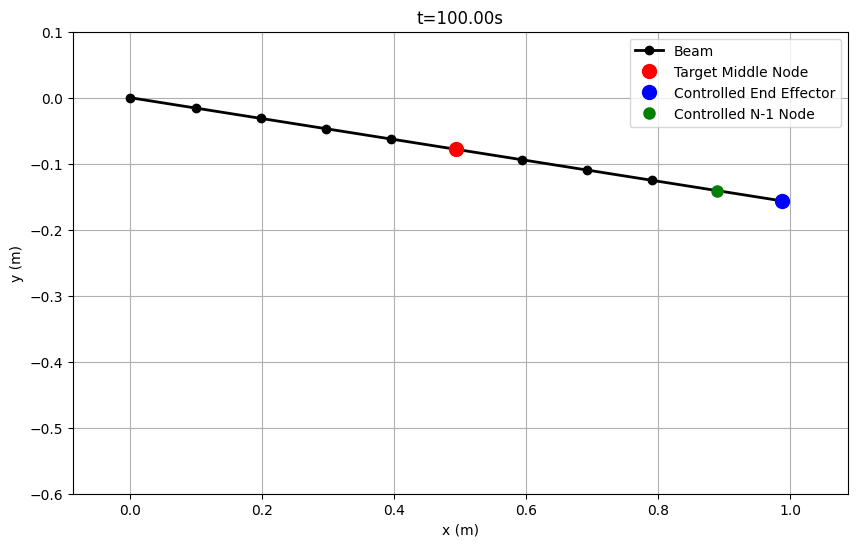

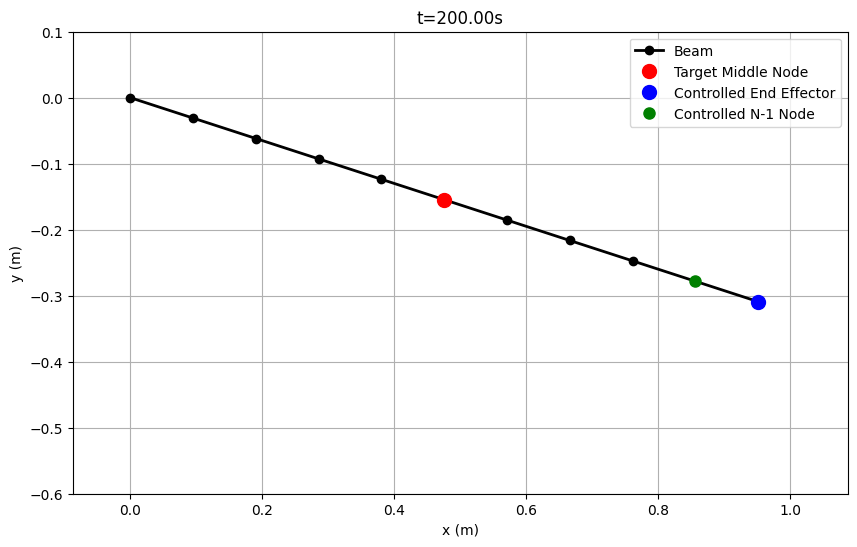

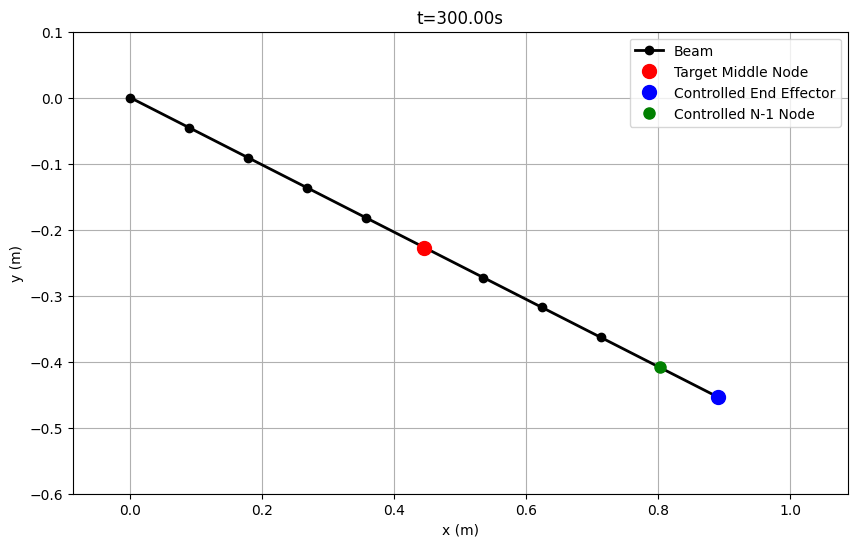

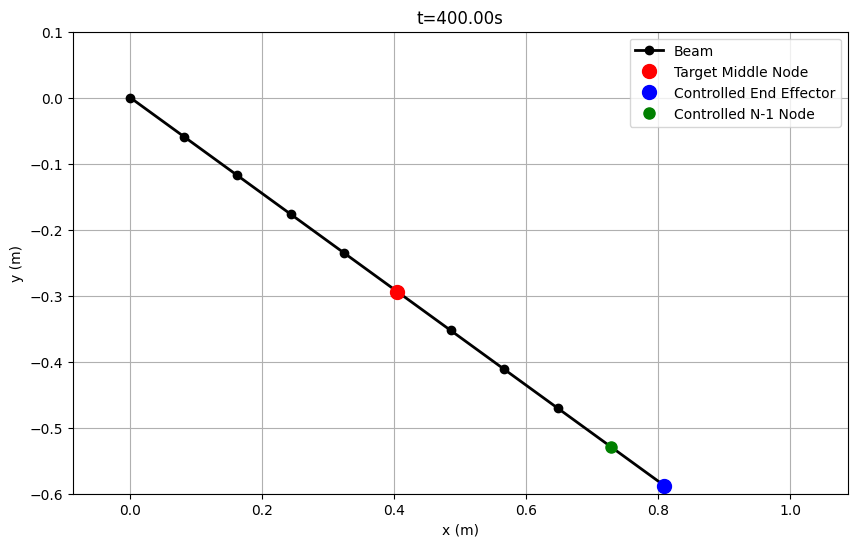

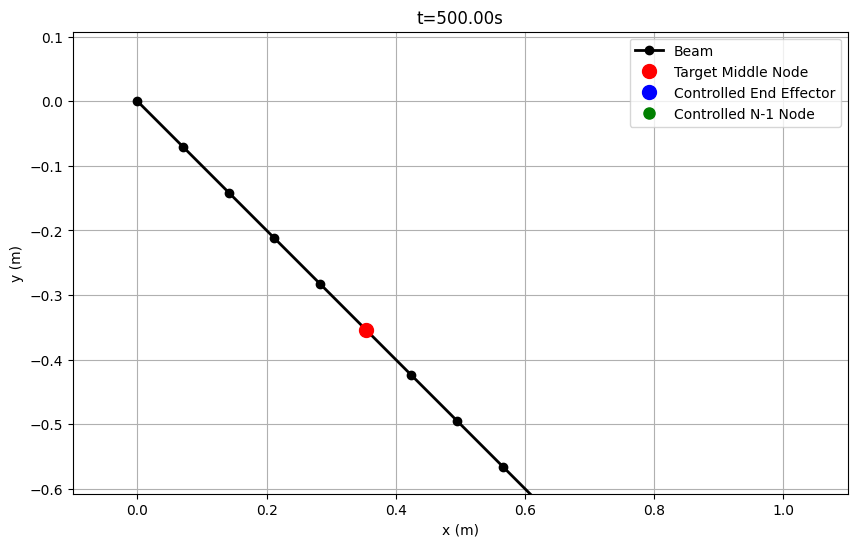

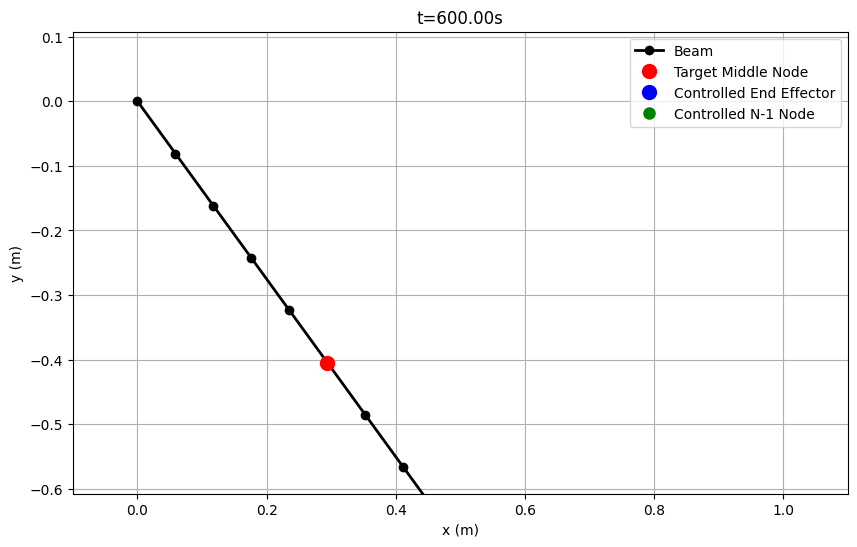

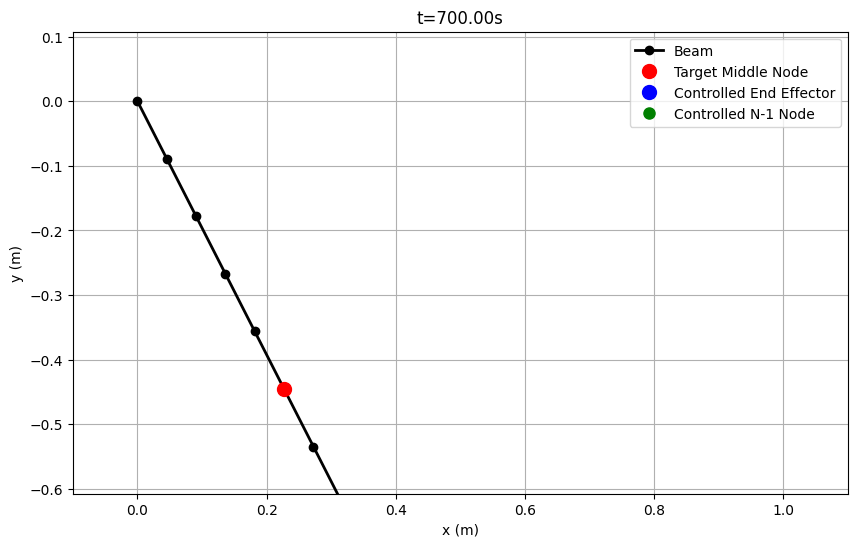

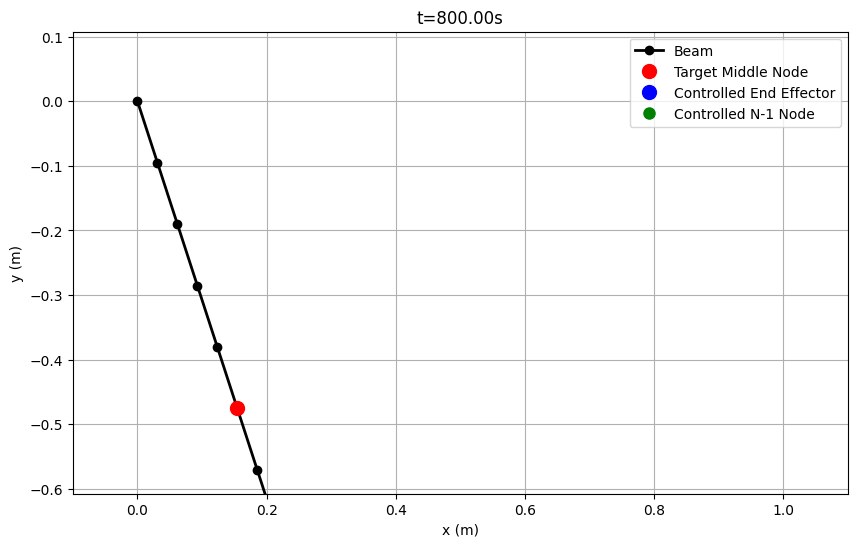

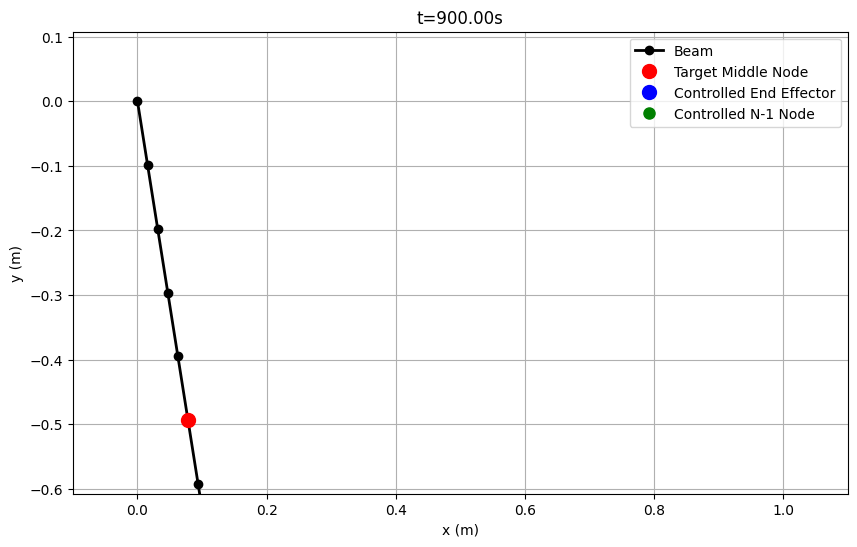

Simulation completed!


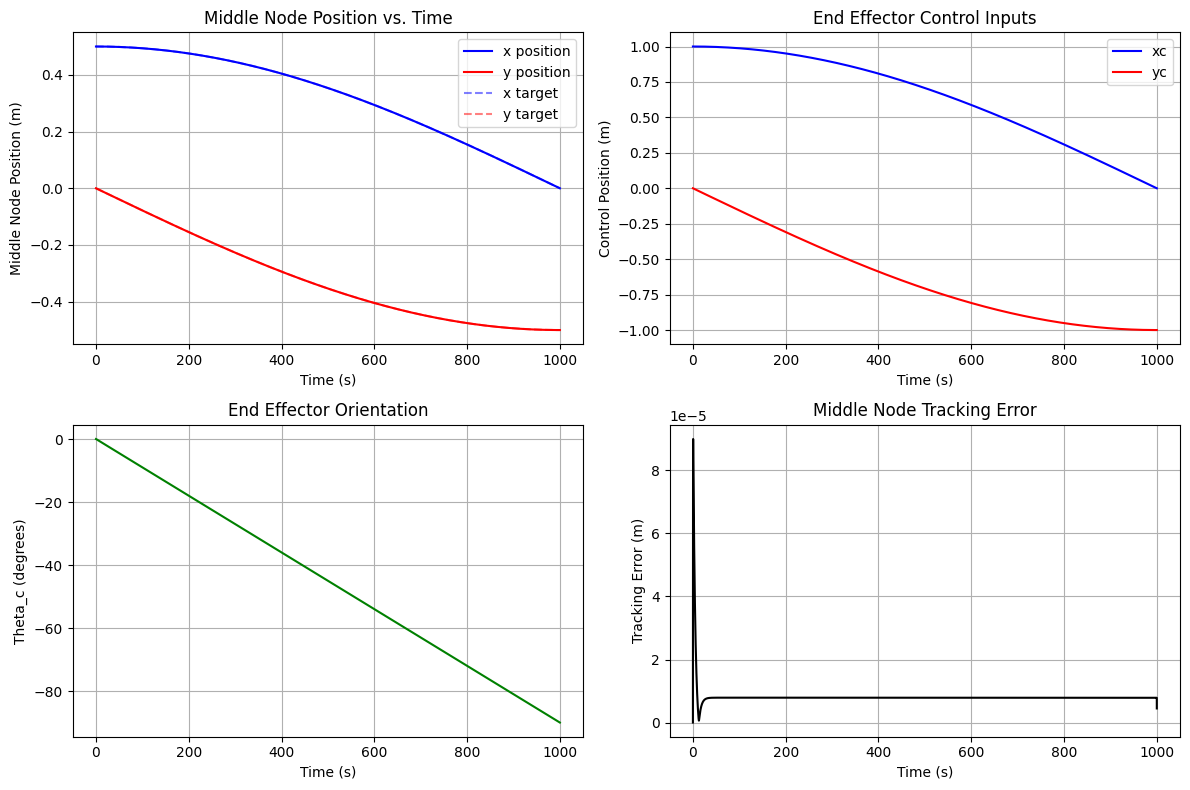

In [ ]:
# Number of steps
Nsteps = round(totalTime / dt)

ctime = 0  # Current time

# Store the middle node information as a function of time
all_mid_pos = np.zeros((Nsteps, 2))
all_mid_vel = np.zeros((Nsteps, 2))
mid_angle = np.zeros(Nsteps)
max_y_displacement = np.zeros(Nsteps)

# Store control inputs and target middle node position
all_xc = np.zeros(Nsteps)
all_yc = np.zeros(Nsteps)
all_theta_c = np.zeros(Nsteps)
all_x_star = np.zeros(Nsteps)
all_y_star = np.zeros(Nsteps)
all_x_n_minus_1_desired = np.zeros(Nsteps)
all_y_n_minus_1_desired = np.zeros(Nsteps)
all_x_n_desired = np.zeros(Nsteps)
all_y_n_desired = np.zeros(Nsteps)

# Initial conditions
q0 = np.zeros(2 * nv)
for c in range(nv):
    q0[2*c] = nodes[c, 0]
    q0[2*c+1] = nodes[c, 1]

u0 = np.zeros(2 * nv)

# Initial boundary conditions (clamped left end)
q0[0] = 0
q0[1] = 0

# Initialize right end to straight configuration
q0[2*(nv-1)] = RodLength
q0[2*(nv-1)+1] = 0.0
q0[2*(nv-2)] = RodLength - deltaL
q0[2*(nv-2)+1] = 0.0

midNode_index = (nv + 1) // 2 - 1

# ============ INITIALIZE PID CONTROLLER ============
controller_state = {
    'xc': RodLength,
    'yc': 0.0,
    'theta_c': 0.0,
    'error_int_x': 0.0,
    'error_int_y': 0.0
}

workspace = {
    'xmin': 0.0,
    'xmax': RodLength,
    'ymin': -RodLength,
    'ymax': 0.0
}

# Store initial values
all_x_star[0], all_y_star[0] = target_node_position(RodLength, ctime)
all_mid_pos[0, 0] = q0[2*midNode_index]
all_mid_pos[0, 1] = q0[2*midNode_index + 1]
all_mid_vel[0, 0] = u0[2*midNode_index]
all_mid_vel[0, 1] = u0[2*midNode_index + 1]

vec_mid_segment_initial = np.array([q0[2*midNode_index] - q0[2*midNode_index-2],
                                    q0[2*midNode_index+1] - q0[2*midNode_index-1]])
mid_angle[0] = np.degrees(np.arctan2(vec_mid_segment_initial[1], vec_mid_segment_initial[0]))
max_y_displacement[0] = np.max(q0[1::2])

all_xc[0] = RodLength
all_yc[0] = 0.0
all_theta_c[0] = 0.0
all_x_n_minus_1_desired[0] = RodLength - deltaL
all_y_n_minus_1_desired[0] = 0.0
all_x_n_desired[0] = RodLength
all_y_n_desired[0] = 0.0

# ============ TIME STEPPING LOOP ============
for timeStep in range(1, Nsteps):
    ctime = timeStep * dt

    # Calculate target middle node position
    x_star, y_star = target_node_position(RodLength, ctime)

    # ============ USE PID CONTROLLER (NOT pathPlanner) ============
    xc, yc, theta_c, x_n_minus_1_desired, y_n_minus_1_desired, x_n_desired, y_n_desired = pidController(
        x_star, y_star, q0, dt, nv, deltaL, controller_state,
        Kp_x=0.15, Kp_y=0.15, Ki_x=0.03, Ki_y=0.03,
        workspace_limits=workspace
    )

    # Store control inputs and targets
    all_xc[timeStep] = xc
    all_yc[timeStep] = yc
    all_theta_c[timeStep] = theta_c
    all_x_star[timeStep] = x_star
    all_y_star[timeStep] = y_star
    all_x_n_minus_1_desired[timeStep] = x_n_minus_1_desired
    all_y_n_minus_1_desired[timeStep] = y_n_minus_1_desired
    all_x_n_desired[timeStep] = x_n_desired
    all_y_n_desired[timeStep] = y_n_desired

    # Apply boundary conditions to initial guess
    q0[2*(nv-2)] = x_n_minus_1_desired
    q0[2*(nv-2)+1] = y_n_minus_1_desired
    q0[2*(nv-1)] = x_n_desired
    q0[2*(nv-1)+1] = y_n_desired

    # Define free DOFs - CRITICAL: exclude BOTH controlled nodes
    controlled_index = np.array([2*(nv-2), 2*(nv-2)+1, 2*(nv-1), 2*(nv-1)+1])
    all_DOFs = np.arange(ndof)
    free_index = np.setdiff1d(all_DOFs, np.concatenate((fixed_index, controlled_index)))

    # Solve for new positions
    q_new, error = objfun(q0, u0, dt, tol, maximum_iter, m, mMat, EI, EA, W,
                          deltaL, free_index)

    if error < 0:
        print(f'Could not converge at time step {timeStep}.')
        break

    # Re-enforce boundary conditions on solution
    q_new[0] = 0
    q_new[1] = 0
    q_new[2*(nv-2)] = x_n_minus_1_desired
    q_new[2*(nv-2)+1] = y_n_minus_1_desired
    q_new[2*(nv-1)] = x_n_desired
    q_new[2*(nv-1)+1] = y_n_desired

    u_new = (q_new - q0) / dt

    # Calculate middle segment angle
    vec_mid_segment = np.array([q_new[2*midNode_index] - q_new[2*midNode_index-2],
                                q_new[2*midNode_index+1] - q_new[2*midNode_index-1]])
    mid_angle[timeStep] = np.degrees(np.arctan2(vec_mid_segment[1], vec_mid_segment[0]))

    # Store middle node position and velocity
    all_mid_pos[timeStep, 0] = q_new[2*midNode_index]
    all_mid_pos[timeStep, 1] = q_new[2*midNode_index + 1]
    all_mid_vel[timeStep, 0] = u_new[2*midNode_index]
    all_mid_vel[timeStep, 1] = u_new[2*midNode_index + 1]

    # Calculate maximum y-displacement
    max_y_displacement[timeStep] = np.max(q_new[1::2])

    q0 = q_new.copy()
    u0 = u_new.copy()

    # Plot
    if timeStep % plotStep == 0:
        x_arr = q_new[::2]
        y_arr = q_new[1::2]

        h1 = plt.figure(1, figsize=(10, 6))
        plt.clf()
        plt.plot(x_arr, y_arr, 'ko-', linewidth=2, markersize=6, label='Beam')
        plt.plot(x_star, y_star, 'ro', markersize=10, label='Target Middle Node')
        plt.plot(xc, yc, 'bo', markersize=10, label='Controlled End Effector')
        plt.plot(x_n_minus_1_desired, y_n_minus_1_desired, 'go', markersize=8, label='Controlled N-1 Node')
        plt.title(f't={ctime:.2f}s')
        plt.xlabel('x (m)')
        plt.ylabel('y (m)')
        plt.axis('equal')
        plt.grid(True)
        plt.legend()
        plt.xlim([-0.1, 1.1])
        plt.ylim([-0.6, 0.1])
        plt.show()

print("Simulation completed!")

# Plot results
t_arr = np.linspace(0, totalTime, Nsteps)

plt.figure(2, figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(t_arr, all_mid_pos[:, 0], 'b-', label='x position')
plt.plot(t_arr, all_mid_pos[:, 1], 'r-', label='y position')
plt.plot(t_arr, all_x_star, 'b--', alpha=0.5, label='x target')
plt.plot(t_arr, all_y_star, 'r--', alpha=0.5, label='y target')
plt.xlabel('Time (s)')
plt.ylabel('Middle Node Position (m)')
plt.title('Middle Node Position vs. Time')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(t_arr, all_xc, 'b-', label='xc')
plt.plot(t_arr, all_yc, 'r-', label='yc')
plt.xlabel('Time (s)')
plt.ylabel('Control Position (m)')
plt.title('End Effector Control Inputs')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(t_arr, np.degrees(all_theta_c), 'g-')
plt.xlabel('Time (s)')
plt.ylabel('Theta_c (degrees)')
plt.title('End Effector Orientation')
plt.grid(True)

plt.subplot(2, 2, 4)
error_x = all_x_star - all_mid_pos[:, 0]
error_y = all_y_star - all_mid_pos[:, 1]
error_mag = np.sqrt(error_x**2 + error_y**2)
plt.plot(t_arr, error_mag, 'k-')
plt.xlabel('Time (s)')
plt.ylabel('Tracking Error (m)')
plt.title('Middle Node Tracking Error')
plt.grid(True)

plt.tight_layout()
plt.show()

if saveImage:
    plt.savefig('control_summary.png')